# Taller de Python para Analítica Bancaria

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marlonleandro/taller-python-banca/blob/main/Caso_Practico_01.ipynb)

## Objetivo del taller

Integrar un flujo completo de análisis de datos en Python para banca:
- carga de datos
- filtros operativos
- cruces entre tablas
- cálculo de KPIs
- obtención de insights accionables de negocio

## Archivos de datos incluidos
- `clientes.csv`
- `cartera_creditos.csv`
- `pagos.csv`

## Instalar librerias necesarias

```shell
python -m pip install pandas
python -m pip install numpy
python -m pip install matplotlib
```

In [1]:
# Importando librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Umbral de alerta de mora (pct)
UMBRAL_ALERTA_MORA = 0.08

In [2]:
# Cargando los datos
clientes = pd.read_csv("./data/clientes.csv")
cartera = pd.read_csv("./data/cartera_creditos.csv", parse_dates=["fecha_desembolso"])
pagos = pd.read_csv("./data/pagos.csv", parse_dates=["fecha_pago"])

print("\n[1] Datos cargados:")
print(f"Clientes: {clientes.shape}")
print(f"Cartera : {cartera.shape}")
print(f"Pagos   : {pagos.shape}")


[1] Datos cargados:
Clientes: (1200, 5)
Cartera : (1800, 15)
Pagos   : (5025, 6)


In [6]:
# Construyendo la cartera activa (Vigente + Refinanciado)
cartera_activa = cartera[cartera["estado_credito"].isin(["Vigente", "Refinanciado"])].copy()

print("\n[2] Cartera activa:")
print(cartera_activa["estado_credito"].value_counts())

cartera_full = cartera_activa.merge(clientes, on="customer_id", how="left")


[2] Cartera activa:
estado_credito
Vigente         1506
Refinanciado     105
Name: count, dtype: int64


In [7]:
# Resumen de pagos por crédito
pagos_resumen = (
    pagos.groupby("loan_id", as_index=False)
         .agg(
            total_pagado=("monto_pagado", "sum"),
            n_pagos=("payment_id", "count"),
            ultimo_pago=("fecha_pago", "max")
         )
)

# Agregando resumen de pagos a la cartera
cartera_full = cartera_full.merge(pagos_resumen, on="loan_id", how="left")
cartera_full["total_pagado"] = cartera_full["total_pagado"].fillna(0)
cartera_full["n_pagos"] = cartera_full["n_pagos"].fillna(0)

cartera_full["en_mora"] = cartera_full["dias_mora"] > 0
cartera_full["mora_critica"] = cartera_full["dias_mora"] > 60
cartera_full["alto_esfuerzo_pago"] = cartera_full["ratio_cuota_ingreso"] > 0.35

In [8]:
# Mostrando resumen de la cartera completa
total_creditos = len(cartera_full)
saldo_total = cartera_full["saldo_actual"].sum()
mora_rate = cartera_full["en_mora"].mean()
mora_critica_rate = cartera_full["mora_critica"].mean()
provision_total = cartera_full["provision"].sum()

print("\n[3] KPI general")
print(f"Total créditos activos      : {total_creditos:,}")
print(f"Saldo total                 : {saldo_total:,.2f}")
print(f"Tasa de mora                : {mora_rate:.2%}")
print(f"Tasa de mora crítica (>60d) : {mora_critica_rate:.2%}")
print(f"Provisión total             : {provision_total:,.2f}")


[3] KPI general
Total créditos activos      : 1,611
Saldo total                 : 59,632,387.87
Tasa de mora                : 8.01%
Tasa de mora crítica (>60d) : 2.48%
Provisión total             : 1,386,256.98


In [9]:
# KPI por segmento de riesgo
kpi_segmento = (
    cartera_full.groupby("segmento", as_index=False)
    .agg(
        clientes_unicos=("customer_id", "nunique"),
        creditos=("loan_id", "count"),
        saldo_total=("saldo_actual", "sum"),
        ticket_promedio=("saldo_actual", "mean"),
        mora_rate=("en_mora", "mean"),
        mora_critica_rate=("mora_critica", "mean"),
        provision_total=("provision", "sum"),
        alto_esfuerzo_rate=("alto_esfuerzo_pago", "mean")
    )
    .sort_values("saldo_total", ascending=False)
)

print("\n[4] KPI por segmento")
kpi_segmento


[4] KPI por segmento


,segmento,clientes_unicos,creditos,saldo_total,ticket_promedio,mora_rate,mora_critica_rate,provision_total,alto_esfuerzo_rate
0,Personas,578,1052,22633462.20,21514.697909,0.066540,0.020913,509449.55,0.138783
2,Pyme,218,398,21761495.99,54677.125603,0.108040,0.032663,545120.52,0.344221
1,Premium,89,161,15237429.68,94642.420373,0.099379,0.031056,331686.91,0.180124


In [10]:
# KPI por segmento y region
kpi_segmento_region = (
    cartera_full.groupby(["segmento", "region"], as_index=False)
    .agg(
        creditos=("loan_id", "count"),
        saldo_total=("saldo_actual", "sum"),
        mora_rate=("en_mora", "mean"),
        provision_total=("provision", "sum")
    )
    .sort_values(["mora_rate", "saldo_total"], ascending=[False, False])
)

print("\n[5] Top focos de riesgo por segmento y región")
kpi_segmento_region.head(10)


[5] Top focos de riesgo por segmento y región


,segmento,region,creditos,saldo_total,mora_rate,provision_total
8,Premium,Oriente,17,2051706.31,0.235294,103071.52
13,Pyme,Oriente,38,2377374.69,0.157895,152532.73
14,Pyme,Sur,45,2466728.06,0.133333,70290.67
3,Personas,Oriente,92,2070053.91,0.130435,73490.89
6,Premium,Lima,64,5985919.76,0.125000,94722.43
11,Pyme,Lima,168,9623794.15,0.113095,224791.75
10,Pyme,Centro,74,3557597.68,0.094595,53985.74
2,Personas,Norte,178,3901284.07,0.089888,125854.70
5,Premium,Centro,25,2230451.31,0.080000,57761.45
0,Personas,Centro,158,3479088.43,0.069620,69657.49


In [11]:
# Construyendo alertas de mora alta
alertas = kpi_segmento_region[kpi_segmento_region["mora_rate"] > UMBRAL_ALERTA_MORA].copy()
alertas["prioridad"] = alertas["mora_rate"].apply(
    lambda x: "Alta" if x > 0.15 else ("Media" if x > 0.10 else "Preventiva")
)

print("\n[6] Alertas de mora alta (>8%)")
alertas.sort_values("mora_rate", ascending=False)


[6] Alertas de mora alta (>8%)


,segmento,region,creditos,saldo_total,mora_rate,provision_total,prioridad
8,Premium,Oriente,17,2051706.31,0.235294,103071.52,Alta
13,Pyme,Oriente,38,2377374.69,0.157895,152532.73,Alta
14,Pyme,Sur,45,2466728.06,0.133333,70290.67,Media
3,Personas,Oriente,92,2070053.91,0.130435,73490.89,Media
6,Premium,Lima,64,5985919.76,0.125000,94722.43,Media
11,Pyme,Lima,168,9623794.15,0.113095,224791.75,Media
10,Pyme,Centro,74,3557597.68,0.094595,53985.74,Preventiva
2,Personas,Norte,178,3901284.07,0.089888,125854.70,Preventiva


In [13]:
# Generando insights adicionales
print("\n[7] Insights accionables")
peor_segmento = kpi_segmento.sort_values("mora_rate", ascending=False).iloc[0]
print(
    f"- El segmento con mayor mora es {peor_segmento['segmento']} "
    f"con {peor_segmento['mora_rate']:.2%}. "
    "Se recomienda revisar originación, políticas de cobranza y campañas preventivas."
)

peor_foco = kpi_segmento_region.sort_values("mora_rate", ascending=False).iloc[0]
print(
    f"- El foco más crítico es {peor_foco['segmento']} / {peor_foco['region']} "
    f"con mora de {peor_foco['mora_rate']:.2%} y saldo de {peor_foco['saldo_total']:,.2f}."
)

alto_esfuerzo = cartera_full.groupby("segmento", as_index=False)["alto_esfuerzo_pago"].mean()
alto_esfuerzo = alto_esfuerzo.sort_values("alto_esfuerzo_pago", ascending=False).iloc[0]
print(
    f"- El mayor ratio de esfuerzo de pago aparece en {alto_esfuerzo['segmento']}. "
    "Podría evaluarse refinanciamiento o reajuste de oferta."
)


[7] Insights accionables
- El segmento con mayor mora es Pyme con 10.80%. Se recomienda revisar originación, políticas de cobranza y campañas preventivas.
- El foco más crítico es Premium / Oriente con mora de 23.53% y saldo de 2,051,706.31.
- El mayor ratio de esfuerzo de pago aparece en Pyme. Podría evaluarse refinanciamiento o reajuste de oferta.


### Guardar resultados en archivos CSV

In [14]:
kpi_segmento.to_csv("./results/reporte_kpi_segmento.csv", index=False)
kpi_segmento_region.to_csv("./results/reporte_kpi_segmento_region.csv", index=False)
alertas.to_csv("./results/reporte_alertas_mora.csv", index=False)

print("\n[8] Archivos generados:")
print("- reporte_kpi_segmento.csv")
print("- reporte_kpi_segmento_region.csv")
print("- reporte_alertas_mora.csv")


[8] Archivos generados:
- reporte_kpi_segmento.csv
- reporte_kpi_segmento_region.csv
- reporte_alertas_mora.csv


## Generando gráficos estadísticos

### 1. Distribución de Cartera por Segmento

Gráfico de barras horizontal que muestra:

- **Cantidad de créditos** por segmento (en azul)
- **Saldo total en millones** por segmento (en púrpura)
- **Aplicación bancaria**: Ver qué segmentos (ej: retail, empresarial, consumo) generan mayor volumen y exposición crediticia.

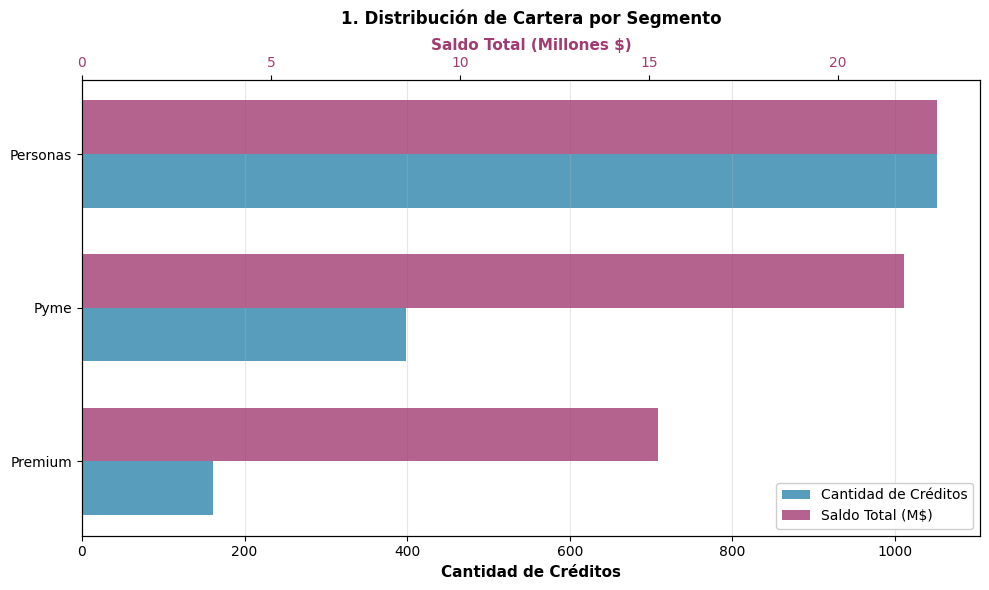

In [15]:
kpi_segmento = (
    cartera_full.groupby("segmento", as_index=False)
    .agg(
        creditos=("loan_id", "count"),
        saldo_total=("saldo_actual", "sum"),
        mora_rate=("en_mora", "mean")
    )
    .sort_values("saldo_total", ascending=True)
)

# Crear gráfico de barras horizontal con dos series
fig, ax1 = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(kpi_segmento))
width = 0.35

ax1.barh(x_pos - width/2, kpi_segmento["creditos"], width, 
                 label='Cantidad de Créditos', color='#2E86AB', alpha=0.8)
ax1_twin = ax1.twiny()
ax1_twin.barh(x_pos + width/2, kpi_segmento["saldo_total"]/1_000_000, width, 
                      label='Saldo Total (M$)', color='#A23B72', alpha=0.8)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(kpi_segmento["segmento"])
ax1.set_xlabel('Cantidad de Créditos', fontsize=11, fontweight='bold')
ax1_twin.set_xlabel('Saldo Total (Millones $)', fontsize=11, fontweight='bold', color='#A23B72')
ax1_twin.tick_params(axis='x', labelcolor='#A23B72')
ax1.set_title('1. Distribución de Cartera por Segmento', fontsize=12, fontweight='bold', pad=10)
ax1.grid(axis='x', alpha=0.3)

# Combinar leyendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', framealpha=0.95)

# Mostrar gráfico
plt.tight_layout()
plt.show()

### 2. Impacto del Esfuerzo de Pago en Mora

Gráfico de barras agrupadas que muestra:

- **Mora general** (naranja) vs Mora crítica (rojo oscuro) por nivel de esfuerzo
- Categorías: Bajo (0-20%), Moderado (20-35%), Alto (35-50%), Crítico (>50%)
- **Aplicación bancaria**: Demuestra que clientes con cuotas más altas **tienen más mora**, evidencia clave para políticas de originación.

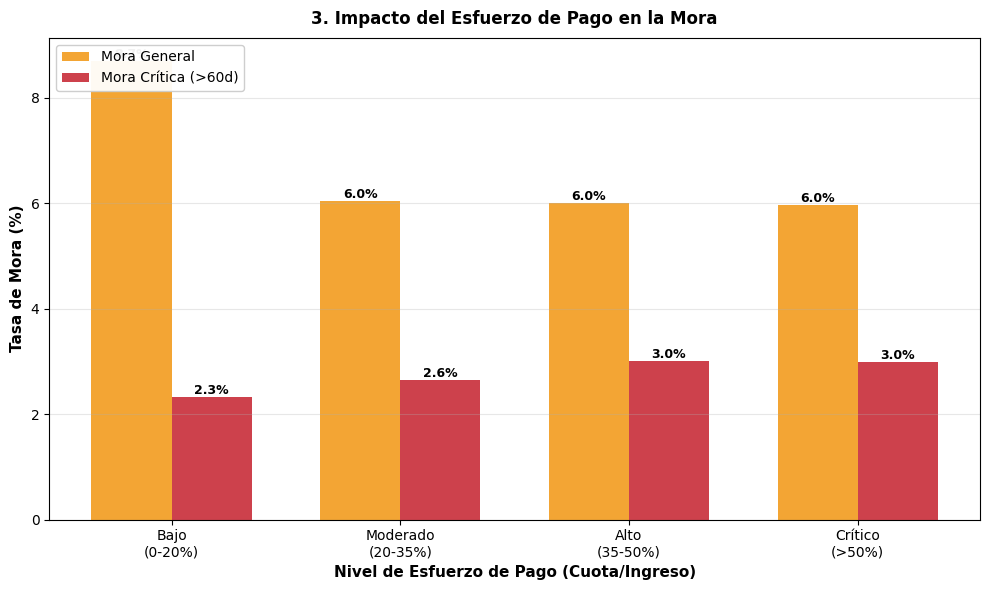

In [16]:
# Crear bins para ratio de cuota/ingreso y calcular mora en cada bin
cartera_full['esfuerzo_bin'] = pd.cut(cartera_full['ratio_cuota_ingreso'], 
                                       bins=[0, 0.20, 0.35, 0.50, 1.0],
                                       labels=['Bajo\n(0-20%)', 'Moderado\n(20-35%)', 
                                              'Alto\n(35-50%)', 'Crítico\n(>50%)'])

relacion_esfuerzo = (
    cartera_full.groupby('esfuerzo_bin', observed=True, as_index=False)
    .agg(
        cantidad_clientes=('customer_id', 'count'),
        mora_rate=('en_mora', 'mean'),
        mora_critica_rate=('mora_critica', 'mean')
    )
)

# Crear gráfico de barras para relación esfuerzo de pago y mora
fig, ax1 = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(relacion_esfuerzo))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, relacion_esfuerzo['mora_rate']*100, width, 
               label='Mora General', color='#F18F01', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, relacion_esfuerzo['mora_critica_rate']*100, width, 
               label='Mora Crítica (>60d)', color='#C1121F', alpha=0.8)

ax1.set_xlabel('Nivel de Esfuerzo de Pago (Cuota/Ingreso)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Tasa de Mora (%)', fontsize=11, fontweight='bold')
ax1.set_title('3. Impacto del Esfuerzo de Pago en la Mora', fontsize=12, fontweight='bold', pad=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(relacion_esfuerzo['esfuerzo_bin'])
ax1.legend(loc='upper left', framealpha=0.95)
ax1.grid(axis='y', alpha=0.3)

# Añadir valores encima de barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
# Mostrar gráficos
plt.tight_layout()
plt.show()